In [248]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv(r"C:\Users\user\Desktop\avito\data\bronze\raw.csv")

In [250]:
df.info()
df.head()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 824 entries, 0 to 823
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   titre          824 non-null    object 
 1   prix           824 non-null    object 
 2   ville          824 non-null    object 
 3   surface        669 non-null    float64
 4   chambres       669 non-null    object 
 5   salle_de_bain  669 non-null    object 
 6   lien           824 non-null    object 
dtypes: float64(1), object(6)
memory usage: 45.2+ KB


(824, 7)

In [251]:
df.isna().sum()

titre              0
prix               0
ville              0
surface          155
chambres         155
salle_de_bain    155
lien               0
dtype: int64

In [252]:
df["surface"] = df["surface"].fillna(df["surface"].median())

In [253]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 824 entries, 0 to 823
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   titre          824 non-null    object 
 1   prix           824 non-null    object 
 2   ville          824 non-null    object 
 3   surface        824 non-null    float64
 4   chambres       669 non-null    object 
 5   salle_de_bain  669 non-null    object 
 6   lien           824 non-null    object 
dtypes: float64(1), object(6)
memory usage: 45.2+ KB


In [254]:
for col in ["chambres", "salle_de_bain", "prix"]:
    df[col] = (
        df[col]
        .astype(str) 
        .str.replace(r"[^\d]", "", regex=True) 
    )
    
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [255]:
df.head()

,titre,prix,ville,surface,chambres,salle_de_bain,lien
0,Appartement à vendre 52 m² à Marrakech,1200000,"Appartements dans Marrakech, Guéliz",52.0,1.0,1.0,https://www.avito.ma/fr/gu%C3%A9liz/appartemen...
1,Appartement 67 m² à BOUSKOURA prix imbattable,690000,"Appartements dans Casablanca, Autre secteur",67.0,2.0,1.0,https://www.avito.ma/fr/autre_secteur/appartem...
2,Appartement à vendre 61 m² à Meknès,380000,"Appartements dans Meknès, Autre secteur",64.0,3.0,2.0,https://www.avito.ma/fr/autre_secteur/appartem...
3,CMN-SI-1879 - Appartement à vendre à Ziraoui,3480000,"Appartements dans Casablanca, Bourgogne",260.0,3.0,2.0,https://www.avito.ma/fr/bourgogne/appartements...
4,Appartements à vendre,1220000,"Appartements dans Agadir, Hay Mohammadi",107.0,3.0,2.0,https://www.avito.ma/fr/hay_mohammadi/appartem...


In [256]:
df[["chambres" , "salle_de_bain" ]] = df[["chambres" , "salle_de_bain"]].fillna(df[["chambres" , "salle_de_bain" ]].median())

In [257]:
df[["chambres", "salle_de_bain"]] = df[["chambres", "salle_de_bain"]].astype(int)

In [258]:
df.head()

,titre,prix,ville,surface,chambres,salle_de_bain,lien
0,Appartement à vendre 52 m² à Marrakech,1200000,"Appartements dans Marrakech, Guéliz",52.0,1,1,https://www.avito.ma/fr/gu%C3%A9liz/appartemen...
1,Appartement 67 m² à BOUSKOURA prix imbattable,690000,"Appartements dans Casablanca, Autre secteur",67.0,2,1,https://www.avito.ma/fr/autre_secteur/appartem...
2,Appartement à vendre 61 m² à Meknès,380000,"Appartements dans Meknès, Autre secteur",64.0,3,2,https://www.avito.ma/fr/autre_secteur/appartem...
3,CMN-SI-1879 - Appartement à vendre à Ziraoui,3480000,"Appartements dans Casablanca, Bourgogne",260.0,3,2,https://www.avito.ma/fr/bourgogne/appartements...
4,Appartements à vendre,1220000,"Appartements dans Agadir, Hay Mohammadi",107.0,3,2,https://www.avito.ma/fr/hay_mohammadi/appartem...


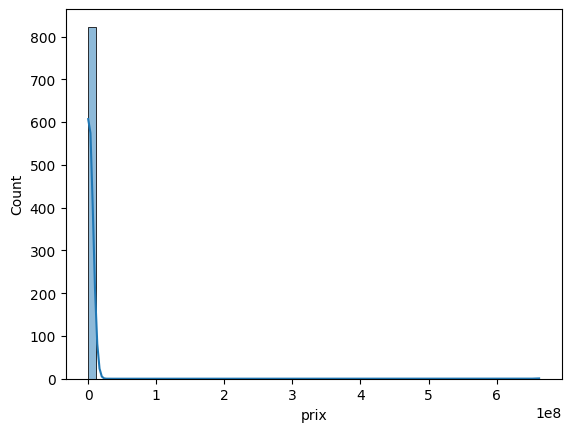

In [259]:
sns.histplot(df["prix" ],kde=True)
plt.show()

In [260]:
df["prix"].skew()

np.float64(28.637421363795138)

In [261]:
Q1 = df["prix"].quantile(0.25)
Q3 = df["prix"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
anomalies = df[(df["prix"] < lower_bound) | (df["prix"] > upper_bound)]
anomalies.shape

(49, 7)

In [262]:
df["prix_m2"] = df["prix"] / df["surface"]
df["prix_m2"] = df["prix_m2"].astype(int)

In [263]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 824 entries, 0 to 823
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   titre          824 non-null    object 
 1   prix           824 non-null    int64  
 2   ville          824 non-null    object 
 3   surface        824 non-null    float64
 4   chambres       824 non-null    int64  
 5   salle_de_bain  824 non-null    int64  
 6   lien           824 non-null    object 
 7   prix_m2        824 non-null    int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 51.6+ KB


In [265]:
df["surface"] = df["surface"].astype(int)

In [266]:
df.to_csv(r"C:\Users\user\Desktop\avito\data\silver\cleaned.csv", index=False)